In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree
import os
import glob


In [2]:
import sys
sys.path.append("/home/z5297792/ESP_zonodo") 
from functions import doppio, doppio_pipeliner

from clim_functions import nencioli


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

res = 1  # 1 km resolution
x_new = np.arange(0, x_grid[-1], res)
y_new = np.arange(0, y_grid[-1], res)
X_new, Y_new = np.meshgrid(x_new, y_new, indexing='ij')
new_points = np.column_stack((X_new.ravel(), Y_new.ravel()))

interp_lon = RegularGridInterpolator((x_grid, y_grid), lon_rho,
                                     method='linear', bounds_error=False, fill_value=np.nan)
interp_lat = RegularGridInterpolator((x_grid, y_grid), lat_rho,
                                     method='linear', bounds_error=False, fill_value=np.nan)

lon_new = interp_lon(new_points).reshape(len(x_new), len(y_new))
lat_new = interp_lat(new_points).reshape(len(x_new), len(y_new))


In [4]:
def interpolate_uv(u, v, X_new, Y_new, angle):
    x_new, y_new = X_new[:,0], Y_new[0,:]

    u_east = np.where(np.abs(u) > 1e30, np.nan, u).astype(float)
    v_north = np.where(np.abs(v) > 1e30, np.nan, v).astype(float)

    u_rot = v_north * np.sin(angle) + u_east * np.cos(angle)
    v_rot = v_north * np.cos(angle) - u_east * np.sin(angle)

    shape_new = X_new.shape
    new_points = np.column_stack((X_new.ravel(), Y_new.ravel()))

    interp_u = RegularGridInterpolator((x_grid, y_grid), u_rot,
                                       method='linear', bounds_error=False, fill_value=np.nan)
    interp_v = RegularGridInterpolator((x_grid, y_grid), v_rot,
                                       method='linear', bounds_error=False, fill_value=np.nan)

    u_new = interp_u(new_points).reshape(shape_new)
    v_new = interp_v(new_points).reshape(shape_new)

    return u_new, v_new


Apply Nencioli (with data inteproalted to 1km). Apply it 1 day at a time, constantly saving the newly updated df. 

In [5]:
# day = 1462
# fnumber = 1461 + ((day - 1462) // 30)*30
# fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_{fnumber:05}.nc'
# dataset = nc.Dataset(fname)
# u_east = np.transpose(dataset['u_eastward'][:].data, axes=(3, 2, 1, 0))[:, :, -1, :].squeeze()
# v_north = np.transpose(dataset['v_northward'][:].data, axes=(3, 2, 1, 0))[:, :, -1, :].squeeze()
# ocean_time = dataset.variables['ocean_time'][:].data / 86400
# t = np.where(day==ocean_time)[0][0]

# # if t.size != 0:
# u, v = u_east[:, :, t], v_north[:, :, t]
# u0, v0 = interpolate_uv(u, v, X_new, Y_new, angle)

# neddy = nencioli(u0.T, v0.T, X_new.T, Y_new.T, 4, 3)[2]
# neddy = neddy[neddy[:, 1].argsort()[::-1]]

# df_nenc = pd.DataFrame(columns=['Day', 'nxc', 'nyc', 'nic', 'njc', 'Cyc'])

# df_nenc['Day'] = [day] * len(neddy)
# df_nenc['nxc'] = neddy[:,0]
# df_nenc['nyc'] = neddy[:,1]

# # find nearest i, j 
# points = np.column_stack((X_grid.ravel(), Y_grid.ravel()))
# tree = cKDTree(points)
# _, idx = tree.query(neddy[:,:2])  # neddy = (N, 2)
# nics, njcs = np.unravel_index(idx, X_grid.shape)
# df_nenc['nic'] = nics
# df_nenc['njc'] = njcs

# df_nenc['Cyc'] = np.where(neddy[:, 2] == -1, 'CE', 'AE')

# plt.figure(figsize=(5, 7))
# cs = np.where(np.abs(np.hypot(u, v)) > 1e30, np.nan, np.hypot(u, v))
# plt.pcolor(X_grid, Y_grid, cs, cmap='Blues_r')
# plt.axis('equal')
# # clrs = np.array(['r'] * len(neddy))
# # clrs[neddy[:,2]==-1] = 'c'
# # plt.scatter(neddy[:,0], neddy[:,1], color=clrs, edgecolors='k', linewidths=0.8, s=60, zorder=10)

# clrs = np.array(['r'] * len(df_nenc))
# clrs[df_nenc.Cyc=='CE'] = 'c'
# # plt.scatter(df_nenc.nxc, df_nenc.nyc, color=clrs, edgecolors='k', linewidths=0.8, s=60, zorder=10)
# plt.scatter(X_grid[df_nenc.nic, df_nenc.njc], Y_grid[df_nenc.nic, df_nenc.njc], color=clrs, edgecolors='k', linewidths=0.8, s=60, zorder=10)

# df_nenc


In [6]:
def find_outer_avg_files(path='/srv/scratch/z3533156/26year_BRAN2020'):
    files = sorted(glob.glob(os.path.join(path, 'outer_avg_*.nc')))
    fnumbers = [int(os.path.basename(f).split('_')[-1].split('.')[0]) for f in files]
    return files, fnumbers

def get_nencioli_df(fnumber, X_new, Y_new, X_grid, Y_grid, angle,
                         a=4, b=3,
                         path='/srv/scratch/z3533156/26year_BRAN2020',
                         plot=False, plot_day_index=15):

    fname = f'{path}/outer_avg_{fnumber:05}.nc'

    points = np.column_stack((X_grid.ravel(), Y_grid.ravel()))
    tree = cKDTree(points)

    dfs = []

    with nc.Dataset(fname) as dataset:
        u_east = np.transpose(dataset['u_eastward'][:].data, axes=(3, 2, 1, 0))[:, :, -1, :].squeeze()
        v_north = np.transpose(dataset['v_northward'][:].data, axes=(3, 2, 1, 0))[:, :, -1, :].squeeze()
        ocean_time = dataset.variables['ocean_time'][:].data / 86400

        for t, day in enumerate(ocean_time):
            day = int(round(day))

            u, v = u_east[:, :, t], v_north[:, :, t]
            u0, v0 = interpolate_uv(u, v, X_new, Y_new, angle)

            neddy = nencioli(u0.T, v0.T, X_new.T, Y_new.T, a, b)[2]

            if len(neddy) == 0:
                continue

            neddy = neddy[neddy[:, 1].argsort()[::-1]]

            df_nenc = pd.DataFrame({
                'Day': day,
                'nxc': neddy[:, 0],
                'nyc': neddy[:, 1],
                'Cyc': np.where(neddy[:, 2] == -1, 'CE', 'AE')
            })

            _, idx = tree.query(neddy[:, :2])
            nics, njcs = np.unravel_index(idx, X_grid.shape)

            df_nenc['nic'] = nics
            df_nenc['njc'] = njcs

            dfs.append(df_nenc)

            if plot and t == plot_day_index:
                plt.figure(figsize=(5, 7))
                cs = np.where(np.abs(np.hypot(u, v)) > 1e30, np.nan, np.hypot(u, v))
                plt.pcolor(X_grid, Y_grid, cs, cmap='Blues_r')
                plt.axis('equal')

                clrs = np.array(['r'] * len(df_nenc))
                clrs[df_nenc.Cyc == 'CE'] = 'c'

                plt.scatter(df_nenc.nxc, df_nenc.nyc, color=clrs,
                            edgecolors='k', linewidths=0.8, s=60, zorder=10)

                plt.title(f'File {fnumber}, day {day}')
                plt.show()

    if len(dfs) == 0:
        return pd.DataFrame(columns=['Day', 'nxc', 'nyc', 'Cyc', 'nic', 'njc'])

    return pd.concat(dfs, ignore_index=True)



In [7]:
save_file = '/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_nenc_SEACOFS_26yr.pkl'

files, fnumbers = find_outer_avg_files()

# --- load existing ---
if os.path.exists(save_file):
    df_nenc_SEACOFS_26yr = pd.read_pickle(save_file)

    last_fnumber = df_nenc_SEACOFS_26yr['fnumber'].max()
    print(f'Resuming from fnumber > {last_fnumber}')

    fnumbers = [f for f in fnumbers if f > last_fnumber]

else:
    df_nenc_SEACOFS_26yr = pd.DataFrame()

# --- main loop ---
for fnumber in fnumbers:

    df_all = get_nencioli_df(
        fnumber, X_new, Y_new, X_grid, Y_grid, angle
    )

    if len(df_all) == 0:
        continue

    df_all['fnumber'] = fnumber  # <-- critical for resume

    df_nenc_SEACOFS_26yr = pd.concat(
        [df_nenc_SEACOFS_26yr, df_all],
        ignore_index=True
    )

    df_nenc_SEACOFS_26yr.to_pickle(save_file)

    print(f'Processed {fnumber}')
    

Processed 1461
Processed 1491
Processed 1521
Processed 1551
Processed 1581
Processed 1611
Processed 1641
Processed 1671
Processed 1701
Processed 1731
Processed 1761
Processed 1791
Processed 1821
Processed 1851
Processed 1881
Processed 1911
Processed 1941
Processed 1971
Processed 2001
Processed 2031
Processed 2061
Processed 2091
Processed 2121
Processed 2151
Processed 2181
Processed 2211
Processed 2241
Processed 2271
Processed 2301
Processed 2331
Processed 2361
Processed 2391
Processed 2421
Processed 2451
Processed 2481
Processed 2511
Processed 2541
Processed 2571
Processed 2601
Processed 2631
Processed 2661
Processed 2691
Processed 2721
Processed 2751
Processed 2781
Processed 2811
Processed 2841
Processed 2871
Processed 2901
Processed 2931
Processed 2961
Processed 2991
Processed 3021
Processed 3051
Processed 3081
Processed 3111
Processed 3141
Processed 3171
Processed 3201
Processed 3231
Processed 3261
Processed 3291
Processed 3321
Processed 3351
Processed 3381
Processed 3411
Processed 

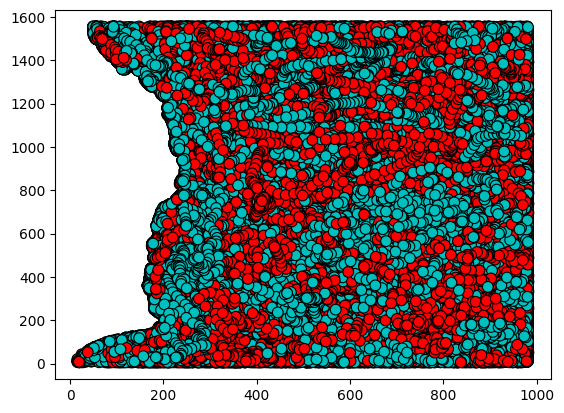

In [10]:
clrs = np.array(['r'] * len(df_nenc_SEACOFS_26yr))
clrs[df_nenc_SEACOFS_26yr.Cyc=='CE'] = 'c'
plt.scatter(df_nenc_SEACOFS_26yr.nxc, df_nenc_SEACOFS_26yr.nyc, color=clrs, edgecolors='k', linewidths=0.8, s=60, zorder=10)
